<a href="https://colab.research.google.com/github/atsuro0415/GCI/blob/main/baseline_advanced_try6_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [ベースライン advanced 版] 第2回データ分析コンペティション：Superstore Marketing Campaign

　このノートブックは **改善サイクル**を体験することが目的です。基準スコアを作り、特徴量・モデル・チューニングを一つずつ試して CV で検証し、スコアを上げていきます。実際、素朴な基準（CV AUC ≈ 0.83）から出発し、工夫を重ねて約 0.85 まで引き上げます。食品スーパーの顧客データから `target`（キャンペーン反応）を予測する二値分類で、評価指標は **AUC** です。本ノートブックは **Google Colab** 上での実行を前提に作られています。

readme
https://colab.research.google.com/drive/1i1-2HoykS3aePBTmGKmouMu0VwOiJ_dv


## 目次

**準備**

- **0/1.** セットアップ・データ読み込み
- **2.** データの概観・EDA
- **3.** 前処理

**基準づくり**

- **4.** ベースラインモデルの構築 — RandomForest と過学習
- **5.** 5-fold クロスバリデーション

**改善サイクル**

- **6.** 特徴量エンジニアリング
- **7.** 様々なモデルの構築・比較
- **8.** モデルのアンサンブリング
- **9.** LightGBM のハイパーパラメータチューニング — Optuna

**仕上げ**

- **10.** 予測の出力・提出
- **11.** まとめと次の打ち手


## 0/1. セットアップ・データ読み込み

In [1]:
# Google Drive のマウント（Colab 上で自分のデータにアクセスするための設定）
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


> **Colab / Google Drive でつまずかないために**
>
> 1. 配布された `train.csv` / `test.csv` / `sample_submission.csv` を自分の Google Drive にアップロードします。上の「データ配置」のように `GCI/competition_2/data/` フォルダを作って入れると分かりやすいです。
> 2. Colab 左側のフォルダアイコンを開き、`drive/MyDrive/...` をたどるとアップロードしたファイルが見えます。ファイルを右クリック →「パスをコピー」で正確なパスを取得できます。
> 3. 下の `PATH` を自分のフォルダのパスに書き換えてください。末尾の `/` を忘れずに。例: `PATH = '/content/drive/MyDrive/GCI/competition_2/data/'`
> 4. `drive.mount(...)` を実行すると認証を求められます。表示されたリンクから Google アカウントを選び、アクセスを許可してください。


In [2]:
# 必要なライブラリのインストール
!pip install japanize-matplotlib lightgbm xgboost optuna --quiet

!pip install catboost --quiet

In [3]:
# モジュールのインポート
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib  # 日本語表示用
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna

warnings.filterwarnings('ignore', category=ConvergenceWarning)

### データ配置

このノートブックではGoogle Drive内において、以下のデータ配置を想定しています。

```
マイドライブ/
└── GCI/
    └── competition_2/
        ├── baseline_advanced.ipynb  # このファイル
        └── data/
            ├── train.csv
            ├── test.csv
            └── sample_submission.csv
```

In [4]:
# 読み込むデータが格納されたディレクトリのパス（※必要に応じて変更してください）
PATH = '/content/drive/MyDrive/Colab_Notebooks/GCI/Competition_2/data/'

In [5]:
train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')
print('Train:', train.shape, ' Test:', test.shape)

Train: (1568, 22)  Test: (672, 21)


　テストに列が 1 つ少ないのは予測対象の `target` が含まれていないためです。これを予測して提出します。

In [6]:
train.head()

,customer_id,birth_year,education_level,marital_status,annual_income,num_children,num_teenagers,registration_date,days_since_last_purchase,spend_wines,...,spend_fish,spend_sweets,spend_gold,deals_purchases,web_purchases,catalog_purchases,store_purchases,monthly_web_visits,has_complaint,target
0,0,1993,Bachelor,Single,70515.0,0,0,2013-10-21,12,420,...,182,64,140,1,6,6,4,2,0,1
1,1,1983,Doctorate,Married,50150.0,0,0,2013-06-20,32,135,...,65,61,11,2,5,2,7,5,0,0
2,2,1992,Master,Single,92859.0,0,0,2012-10-19,46,962,...,52,61,20,1,5,4,12,2,0,0
3,3,1962,Doctorate,Partner,56067.0,0,1,2013-07-20,51,517,...,16,6,120,2,7,4,7,5,0,0
4,4,1967,Doctorate,Partner,56575.0,0,2,2013-05-05,42,421,...,0,16,10,3,7,3,7,5,0,0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1568 entries, 0 to 1567
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1568 non-null   int64  
 1   birth_year                1568 non-null   int64  
 2   education_level           1568 non-null   object 
 3   marital_status            1568 non-null   object 
 4   annual_income             1553 non-null   float64
 5   num_children              1568 non-null   int64  
 6   num_teenagers             1568 non-null   int64  
 7   registration_date         1568 non-null   object 
 8   days_since_last_purchase  1568 non-null   int64  
 9   spend_wines               1568 non-null   int64  
 10  spend_fruits              1568 non-null   int64  
 11  spend_meat                1568 non-null   int64  
 12  spend_fish                1568 non-null   int64  
 13  spend_sweets              1568 non-null   int64  
 14  spend_go

## 2. データの概観・EDA

　モデルを作る前に、データの状態を確認します。欠損がないか、カテゴリ値はどんな文字列か、分布に偏りはないか。ここで見つけた課題が、3章の前処理で解決すべき問題になります。

### 欠損値の確認

　多くのモデルは欠損値があると学習できません。まず「どの列に何件の欠損があるか」を確認します。

In [8]:
train.isnull().sum()

,0
customer_id,0
birth_year,0
education_level,0
marital_status,0
annual_income,15
num_children,0
num_teenagers,0
registration_date,0
days_since_last_purchase,0
spend_wines,0


In [9]:
test.isnull().sum()

,0
customer_id,0
birth_year,0
education_level,0
marital_status,0
annual_income,9
num_children,0
num_teenagers,0
registration_date,0
days_since_last_purchase,0
spend_wines,0


In [42]:
train.describe()

,birth_year,education_level,marital_status,annual_income,num_children,num_teenagers,days_since_last_purchase,spend_wines,spend_fruits,spend_meat,...,children_total,Ratio_of_totalspend_to_income,Use_whithin_month,total_purchases,deals_ratio,spend_per_purchase,has_children,income_per_member,age_x_spend,web_conversion
count,1568.000000,1568.000000,1568.000000,1568.000000,1568.000000,1568.000000,1568.000000,1568.000000,1568.000000,1568.000000,...,1568.000000,1568.000000,1568.000000,1568.00000,1568.000000,1568.000000,1568.000000,1568.000000,1568.000000,1568.000000
mean,1968.823342,1.684311,2.195153,52393.147321,0.435587,0.504464,49.071429,304.494898,26.155612,167.141582,...,0.940051,0.009634,0.610332,14.90625,0.164714,30.648576,0.707908,34010.218378,34282.751276,0.799105
std,12.023484,1.203784,1.478258,26667.770456,0.528386,0.541788,28.840759,337.010658,39.741202,223.495895,...,0.749543,0.008100,0.487831,7.65569,0.102883,27.438555,0.454869,26380.306208,35558.894260,0.861279
min,1893.000000,0.000000,0.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000039,0.000000,0.00000,0.000000,0.500000,0.000000,1341.000000,255.000000,0.000000
25%,1959.000000,1.000000,1.000000,35409.000000,0.000000,0.000000,24.750000,23.000000,1.000000,16.000000,...,0.000000,0.002294,0.000000,8.00000,0.073413,8.333333,0.000000,15392.541667,3520.000000,0.285714
50%,1970.000000,1.000000,3.000000,51412.000000,0.000000,0.000000,49.000000,172.000000,8.000000,67.500000,...,1.000000,0.008135,1.000000,15.00000,0.157895,21.817857,1.000000,24971.916667,20963.500000,0.666667
75%,1977.000000,2.000000,3.000000,68363.250000,1.000000,1.000000,74.000000,508.000000,33.000000,230.000000,...,1.000000,0.015424,1.000000,21.00000,0.250000,43.208333,1.000000,39026.500000,57325.500000,1.229167
max,1996.000000,4.000000,5.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,...,3.000000,0.081075,1.000000,44.00000,0.937500,160.857143,1.000000,333333.000000,231625.000000,23.000000


　`annual_income` に欠損があります。3章でこれを補完します。

In [10]:
#欠損値ありと年収の関係
# 補完前のtrainで確認（前処理セルより前に実行する必要あり）
train_raw = pd.read_csv(PATH + 'train.csv')

train_raw['income_missing'] = train_raw['annual_income'].isna().astype(int)
missing_rate = train_raw.groupby('income_missing')['target'].mean()
print(missing_rate)
print(f"\n欠損あり反応率: {missing_rate[1]:.3f}")
print(f"欠損なし反応率: {missing_rate[0]:.3f}")
print(f"差: {missing_rate[1] - missing_rate[0]:+.3f}")

income_missing
0    0.150032
1    0.066667
Name: target, dtype: float64

欠損あり反応率: 0.067
欠損なし反応率: 0.150
差: -0.083


### クラスバランス

　目的変数 `target` がどれくらい偏っているかを確認します。今回のコンペの評価指標は AUC と決められていますが、データの偏りを知っておくと、なぜ AUC で測るのか、どう取り組めばよいかが見えてきます。

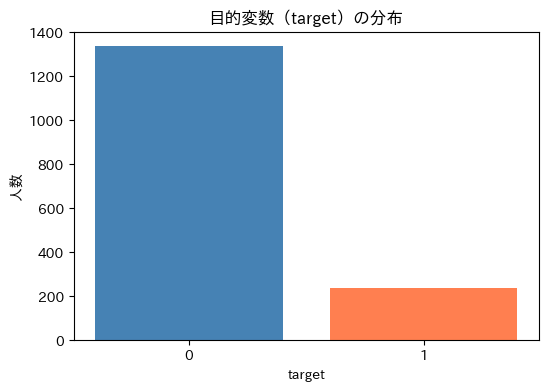

In [11]:
target_counts = train['target'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values, color=['steelblue', 'coral'])
plt.xlabel('target')
plt.ylabel('人数')
plt.title('目的変数（target）の分布')
plt.show()

In [12]:
target_pct = train['target'].value_counts(normalize=True) * 100
print(f"target=0（非反応）: {target_pct[0]:.1f}%")
print(f"target=1（反応）  : {target_pct[1]:.1f}%")

target=0（非反応）: 85.1%
target=1（反応）  : 14.9%


　反応あり `target=1` は全体の **約15%（およそ7人に1人）** にとどまる少数派で、偏りのある不均衡データです。もし正解率で測ると、全員「反応なし」と予測するだけで **約85%が当たってしまい**、良いモデルに見えてしまいます。本コンペで指定されている評価指標 **AUC** は、こうした不均衡データでも適切に測れる指標です。AUC は「反応する人に高い確率を付けられたか」という順位付けの良さを、0.5 がランダム・1.0 が完璧として表します。確率の細かい値そのものではなく、反応する人を上位に並べられたかで測るため、偏りのあるデータでも安定して評価できます。

### 数値特徴量の分布

　ヒストグラムで、分布の形・偏り・値の大きさ（スケール）を確認します。列によって値の桁が大きく違うことがありますが、その違いをどう扱うかは使うモデルによって変わります。詳しくは7章で説明します。

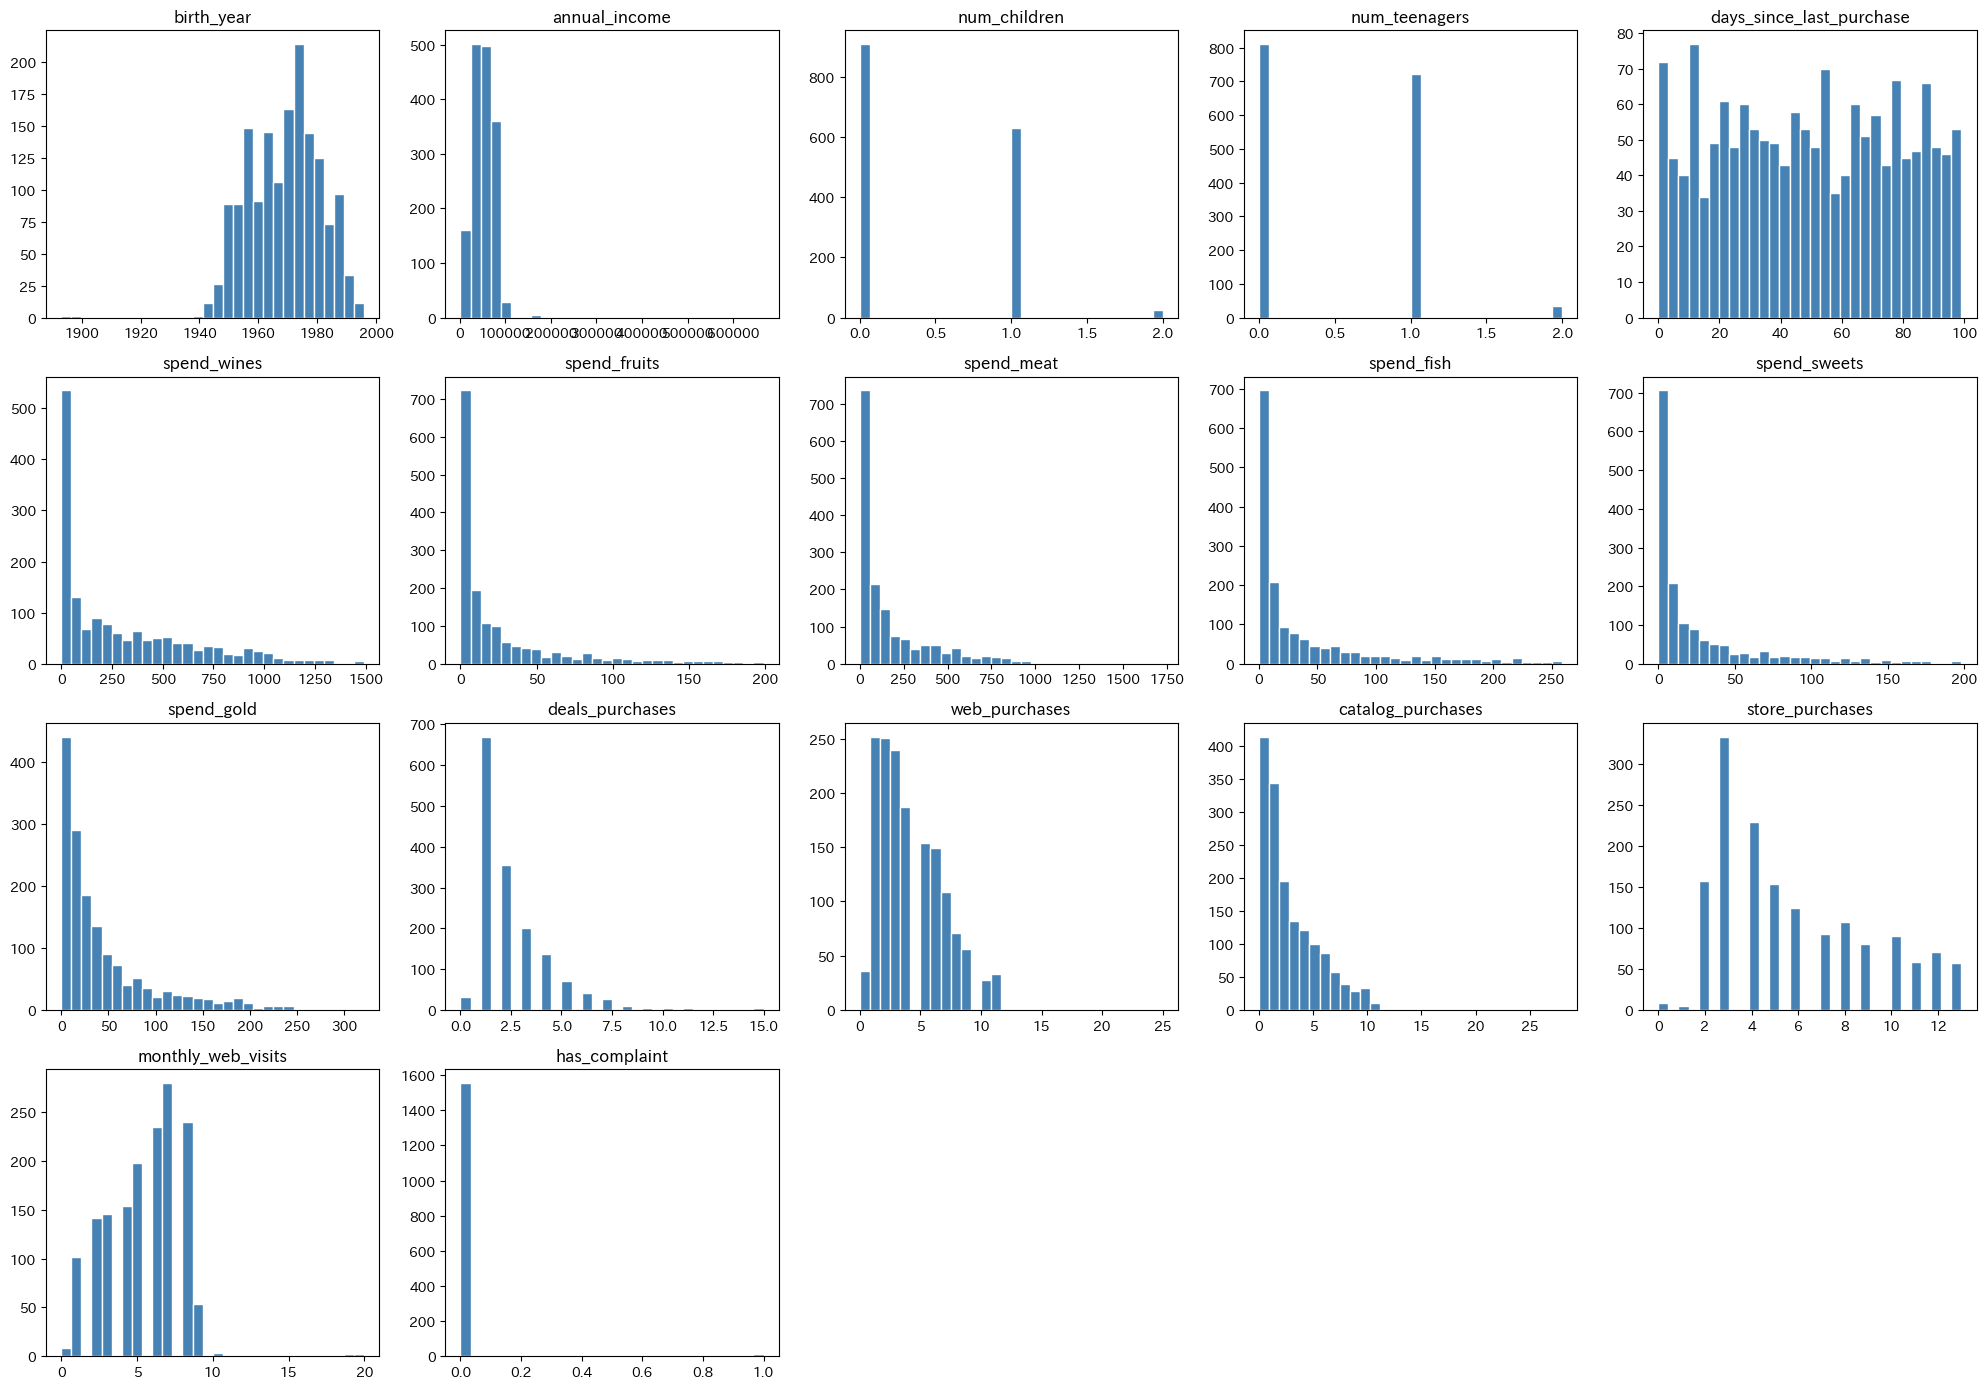

In [13]:
# 数値列だけを取り出す（customer_id, target列は除く）
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = [c for c in numeric_cols if c not in ['customer_id', 'target']]

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(train[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

　`birth_year` は年齢に変換すると反応との関係を捉えやすくなります（6章で `age` を作ります）。`spend_*` 系はどれも「少額の人が多く、高額の人は少しだけ」という似た形の分布です。商品ごとの消費額を合計すれば、その人の総消費を表す `total_spend` を作れそうです。`days_since_last_purchase` は値が小さいほど最近買った顧客で、よく利用している顧客ほどキャンペーンに反応しやすいかもしれません。

### カテゴリ特徴量の分布と目的変数との関係

　`education_level` と `marital_status` を 2 つの見方で確認します。まず、それぞれのカテゴリにどんな値がどれくらいあるか（件数の分布）を見ます。

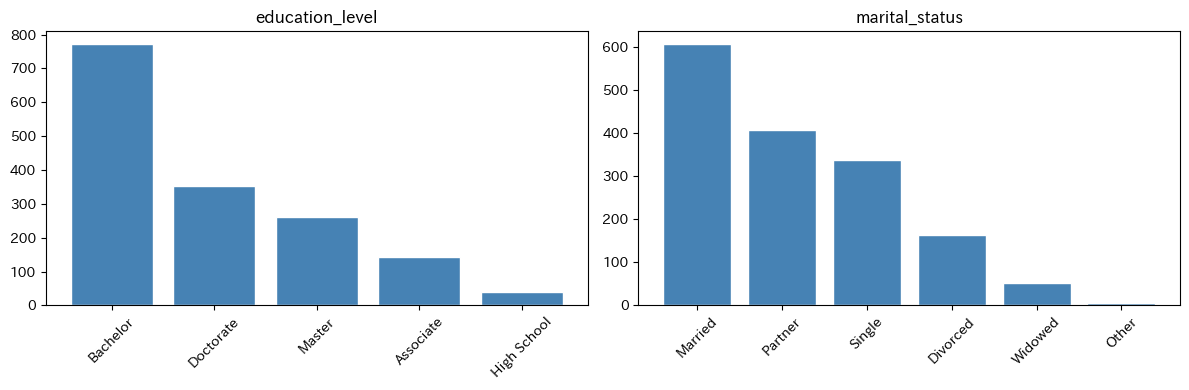

In [14]:
categorical_cols = ['education_level', 'marital_status']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(categorical_cols):
    counts = train[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


　件数の分布を確認しました。次に、各カテゴリ値ごとの `target` 平均（反応率）を確認します。カテゴリによって反応率に差があれば、そのカテゴリは予測の手がかりになりやすいです。

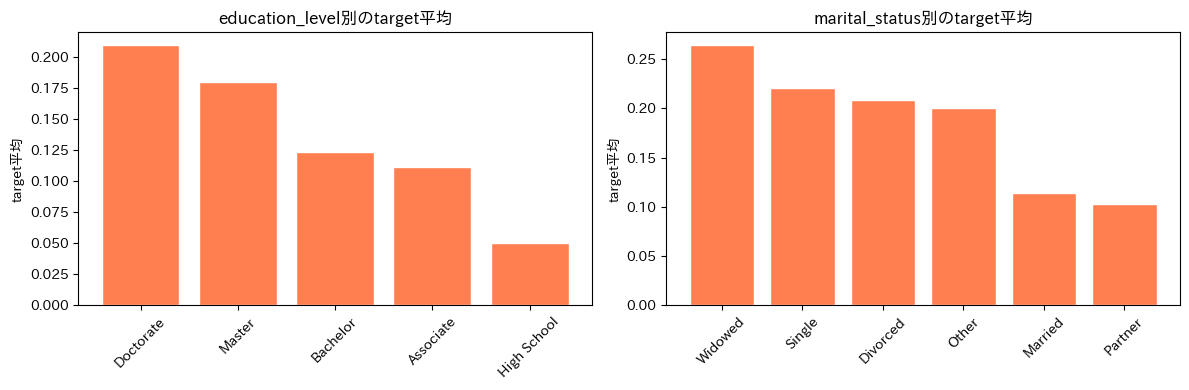

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(categorical_cols):
    target_mean = train.groupby(col)['target'].mean().sort_values(ascending=False)
    axes[i].bar(target_mean.index, target_mean.values, color='coral', edgecolor='white')
    axes[i].set_title(f'{col}別のtarget平均')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('target平均')
plt.tight_layout()
plt.show()

　カテゴリ値によって反応率に差があれば、Target Encoding（カテゴリ値を target 平均で置き換える手法）といった、より進んだ前処理の発想にも繋がります。

### 相関ヒートマップ

　相関には 2 つの読みどころがあります。1 つは **どの特徴量が `target` と関係していそうか**。相関が高い列ほど、予測の手がかりになりやすいです。もう 1 つは **特徴量どうしの関係**で、よく似た動きをする列は同じような情報を持っていると分かります。こうして列どうしの関係が見えると、「`target` と相関の高い列をまとめて合計したり比率にしたりすれば、もっと効く特徴量を作れないか」という仮説につながります。

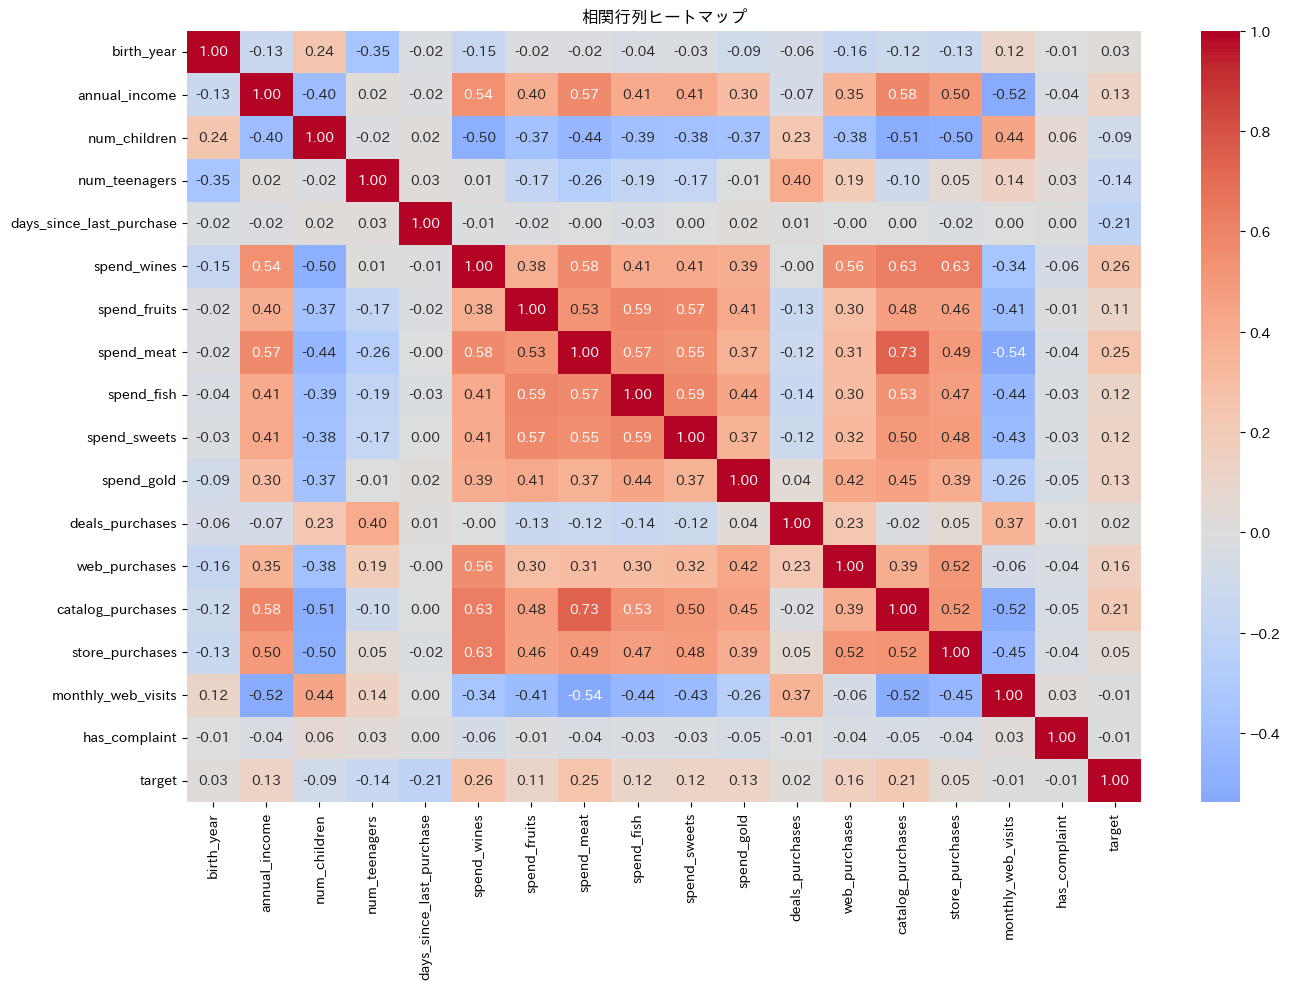

In [16]:
# 数値列だけを取り出す（customer_id列は除く）
numeric_for_corr = train.select_dtypes(include=['number']).drop(columns=['customer_id'])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('相関行列ヒートマップ')
plt.tight_layout()
plt.show()

　予想どおり、`spend_wines`・`spend_meat` や `catalog_purchases` は `target` と正の相関を示します。よく買う顧客ほどキャンペーンに反応しやすい、という素直な関係です。たとえば `spend_*` をまとめた `total_spend`（消費額の合計）のような特徴量が効きそうです。これは6章で検証します。

　ここで目を引くのが、`days_since_last_purchase` が `target` と**負の相関**を示すことです。なぜマイナスなのでしょうか。この列は「最終購入からの経過日数」で、値が小さいほど最近買った顧客を表します。つまり**最近買った顧客ほどキャンペーンに反応しやすい**わけで、向きが逆だからこそ負の相関として現れます。相関の符号をそのまま受け取らず、「その列が何を意味するか」と結びつけて読む——これが EDA の大事な勘どころです。

　EDA の目的は、こうした仮説を立てることです。課題も見えてきました。欠損がある・カテゴリが文字列のまま・不要な列がある。次の3章でこれらを解決します。

### 各カラムの意味

予測に使う前に、各列が何を表すのかを確認しておきましょう。

| カラム名 | 意味 |
|---|---|
| customer_id | 顧客ID（予測には使いません） |
| birth_year | 生まれ年 |
| education_level | 学歴 |
| marital_status | 配偶状況 |
| annual_income | 年収 |
| num_children | 子供の人数 |
| num_teenagers | ティーンエイジャーの人数 |
| registration_date | 顧客の登録日 |
| days_since_last_purchase | 最終購入からの経過日数 |
| spend_wines | ワインへの消費額 |
| spend_fruits | 果物への消費額 |
| spend_meat | 肉類への消費額 |
| spend_fish | 魚類への消費額 |
| spend_sweets | 菓子への消費額 |
| spend_gold | 金製品への消費額 |
| deals_purchases | 割引での購入回数 |
| web_purchases | Web サイト経由の購入回数 |
| catalog_purchases | カタログ経由の購入回数 |
| store_purchases | 実店舗での購入回数 |
| monthly_web_visits | 月あたりの Web サイト訪問回数 |
| has_complaint | 過去に苦情を申し立てたか（1=あり） |
| target | キャンペーンに反応したか（1=反応）。**これが予測対象です** |

`spend_` で始まる列は「その商品カテゴリにいくら使ったか」、`_purchases` で終わる列は「そのチャネルで何回買ったか」を表します。


## 3. 前処理

　EDA で「欠損がある」「カテゴリが文字列のまま」「不要な列がある」という課題が見えました。モデルが学習できる形に整えるため、3 つの処理を行います：①欠損値の補完、②カテゴリ変数の数値化、③不要な列の削除。

### ① 欠損値の補完

　`annual_income` の欠損を補完します。train の**中央値**を使います。年収のように「一部の高い人が平均を押し上げる」データでは、平均より中央値（ちょうど真ん中の値）の方が、多くの人に近い代表値になります。test も、train で計算したのと同じ中央値で補完します。もし test 自身の値から中央値を計算すると、本番では知り得ないはずの test の情報を前処理にこっそり使うことになります。これを **情報漏洩（リーク）** と呼び、手元の評価だけが本番より良く見えてしまう原因になります。

In [17]:
median_income = train['annual_income'].median()
for df in [train, test]:
    df['annual_income'] = df['annual_income'].fillna(median_income)

### ② カテゴリ変数の数値化 — ラベルエンコーディング

　`education_level` と `marital_status` は文字列なのでモデルがそのままでは扱えません。0, 1, 2, … の整数に変換します（ラベルエンコーディング）。決定木系は「ある値を境に枝分かれする」仕組みなので、整数の大小（順序）は気にしません。一方、線形モデルやニューラルネットは `重み × 値` の計算をするため、順序のないカテゴリに誤った大小関係を与えてしまいます。たとえば `marital_status` が `Single→0, Married→1, Together→2` と変換されたとすると、線形モデルは「Together(2) は Married(1) の 2 倍」のように数値の大小をそのまま意味として受け取り、本来順序のないカテゴリに勝手な順位をつけて学習してしまいます。それを避けるには各カテゴリを 0/1 のフラグ列に分ける One-Hot エンコーディングが向いています。7章では主に決定木系を使うのでラベルエンコーディングを採用します。

　なお、この方法は test に train と同じカテゴリ値が含まれていることを前提にしています。未知のカテゴリが出現した場合はエラーになるので注意してください。

In [18]:
for col in ['education_level', 'marital_status']:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))



In [19]:
for df in [train, test]:
    df['customer_tenure'] = 2024 - pd.to_datetime(df['registration_date'], errors='coerce').dt.year

# NaN埋め（trainの中央値で補完）
median_tenure = train['customer_tenure'].median()
for df in [train, test]:
    df['customer_tenure'] = df['customer_tenure'].fillna(median_tenure)


### ③ 不要な列の削除

　`customer_id` はただの識別番号で、残すと「ID > 1000 は反応しやすい」という偶然のパターンを過学習します。`registration_date` は文字列の日付なのでそのままでは使えません。在籍日数などに変換すれば特徴量として活かせるかもしれませんが、今回は使いません。

In [20]:
for df in [train, test]:
    df.drop(columns=['customer_id','registration_date'], inplace=True)
print('Train欠損:', train.isnull().sum().sum(), ' 列:', list(train.columns))

Train欠損: 0  列: ['birth_year', 'education_level', 'marital_status', 'annual_income', 'num_children', 'num_teenagers', 'days_since_last_purchase', 'spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold', 'deals_purchases', 'web_purchases', 'catalog_purchases', 'store_purchases', 'monthly_web_visits', 'has_complaint', 'target', 'customer_tenure']


　欠損がなくなり、全列が数値になりました。これでモデルに渡せる状態です。次は、これから試す工夫の **比較の基準**（ベースライン）となるモデルを作ります。次の章ではまず、わざと複雑すぎる設定のモデルを作り、そこで起きる **過学習** という現象を観察するところから始めます。

## 4. ベースラインモデルの構築 — RandomForest と過学習

　工夫の効果を測るには、出発点となる**基準スコア**が必要です。そこでまず **RandomForest** で素朴なモデルを作ります。RandomForest は、「`annual_income` が ○○ 以上か？」のような条件で枝分かれして予測する**決定木**をたくさん作り、その多数決で予測するモデルです。

　学習のしかたを観察するため、データを学習用（Train）と検証用（Valid）に分け、両方で AUC を測って見比べます。ここではあえて木を深く伸ばせる（複雑になりすぎる）設定にして、**過学習**がどう起きるかをわざと観察します。

In [21]:
X = train.drop(columns=['target'])
y = train['target']
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)
train_auc = roc_auc_score(y_tr, rf.predict_proba(X_tr)[:, 1])
valid_auc = roc_auc_score(y_va, rf.predict_proba(X_va)[:, 1])
print(f'Train AUC = {train_auc:.4f}')
print(f'Valid AUC = {valid_auc:.4f}')

Train AUC = 0.9999
Valid AUC = 0.8284


　結果を見ると、**Train AUC は約 1.00 とほぼ完璧なのに、Valid AUC は約 0.83 にとどまります**。この大きな差（約 0.17）が**過学習**のサインです。過学習とは「過去問を丸暗記して本番の初見問題に対応できない」状態で、モデルが学習データのノイズまで覚えています。

　ではどうすれば抑えられるでしょうか。木を浅くする（`max_depth` を小さくする）と複雑さが下がり、過学習は和らぎます。ただし浅くしすぎると今度は学習不足になります。`max_depth` を変えて、その差がどう動くか観察しましょう。

In [22]:
for d in [None, 10, 5, 3]:
    m = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42).fit(X_tr, y_tr)
    tr = roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1])
    va = roc_auc_score(y_va, m.predict_proba(X_va)[:, 1])
    print(f'max_depth={str(d):>4}:  Train={tr:.4f}  Valid={va:.4f}  gap={tr-va:.4f}')

max_depth=None:  Train=0.9999  Valid=0.8284  gap=0.1715
max_depth=  10:  Train=0.9995  Valid=0.8324  gap=0.1672
max_depth=   5:  Train=0.9558  Valid=0.8240  gap=0.1318
max_depth=   3:  Train=0.8738  Valid=0.8153  gap=0.0584


　狙いどおり、`max_depth` を小さくすると差が縮みました。制約なしでは Train 1.00 / Valid 0.83 で差は約 0.17 でしたが、`max_depth=3` では Train 0.87 / Valid 0.81、差は約 0.06 まで縮みます。ちょうどよい強さは次章で探りますが、この「単純すぎても複雑すぎてもうまくいかない」というバランス感覚は、機械学習で何度も出会う基本的な考え方です。

　なお今は 1 回の分割で測っているだけなので、たまたま良い／悪いだけかもしれません。次は、より信頼できる測り方に進みます。

## 5. 5-fold クロスバリデーション

　4章の 1 回分割は「たまたまその分割が高い／低い」という運の影響を受けます。試験を 1 回受けるだけでは実力か運か分からないのと同じです。この不安定さを解決するのが **5-fold CV** です。

　データを 5 つのブロックに分け、「1 つを検証用・残り 4 つを学習用」を 5 回繰り返して AUC の平均を取ります。この **CV AUC** が以降のすべての改善の比較基準になります。`StratifiedKFold` は各 fold で「反応あり（target=1）の割合」を元のデータと揃えるため、偏りのあるデータで重要です。

　コードの `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` の意味は次のとおりです。

- `n_splits=5`：分けるブロック数。多いほど評価は安定するが計算は重くなる。5 が標準的
- `Stratified`（層化）：各ブロックで「反応ありの割合」を元データと揃える。偏りのあるデータで評価がブレないために重要
- `shuffle=True`：分割前にデータをシャッフルし、並び順の偏りを防ぐ
- `random_state=42`：乱数の種を固定。何度実行しても同じ分割になり、再現性が保てる

In [23]:
def cv_auc(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        m = clone(model)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        p = m.predict_proba(X.iloc[va_idx])[:, 1]
        scores.append(roc_auc_score(y.iloc[va_idx], p))
    return np.mean(scores), scores

rf = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)
baseline_cv, folds = cv_auc(rf, X, y)
print('各foldのAUC:', [f'{s:.4f}' for s in folds])
print(f'基準スコア（CV平均AUC）= {baseline_cv:.4f}')

各foldのAUC: ['0.8964', '0.8019', '0.8350', '0.8440', '0.8174']
基準スコア（CV平均AUC）= 0.8389


　5 つの fold の平均 AUC は **約 0.83** でした。これがこのデータの**基準スコア**です。以降に試す工夫はすべて、この **0.83 を上回れるか**で判断します。これで「工夫してスコアが本当に上がったか」を、運に左右されず安定して測れます。次は、その基準を上げにいきます。まずは特徴量から試します。

## 6. 特徴量エンジニアリング

　基準スコアを上げにいきます。最初の打ち手は**特徴量エンジニアリング**です。「LightGBM のような強いモデルなら、列を足し合わせた特徴くらい自動で見つけてくれそう」と思うかもしれません。けれど決定木は 1 列ずつ条件で枝分かれするため、「6 種類の消費額の合計」のような**複数列をまとめた値**は直接は捉えにくいのです。あらかじめ列として計算して渡すと、浅い木でもそれを手がかりにできます。つまり、人が「効きそう」と考えた組み合わせを、あらかじめ列（特徴量）として作って渡すと、モデルが学習しやすくなります。そこで、EDA で立てた仮説を元に新しい特徴量を作って追加し、CV でスコアが上がるかを確認します。

　2章の仮説を 2 つ試します。

- `age`：年齢は生まれ年より反応率と関係しやすい
- `total_spend`：`spend_*`（6 種類の消費額）の合計。よく使う顧客ほど反応しやすい、という仮説

In [24]:
spend_cols = ['spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold']
for df in [train, test]:
    df['age'] = 2024 - df['birth_year']  # 基準年は便宜上の固定値。大小関係が保てればよい
    df['total_spend'] = df[spend_cols].sum(axis=1)  # spend_* 6列の合計
    df["children_total"] = df["num_children"] + df["num_teenagers"] #子供のデータ
    df["Ratio_of_totalspend_to_income"] = df["total_spend"] / df["annual_income"]  #所得に対する総消費
    df["Use_whithin_month"] = (df['days_since_last_purchase'] <= 60).astype(int)
    # 総購入回数（チャネル合計）
    df['total_purchases'] = df['web_purchases'] + df['catalog_purchases'] + df['store_purchases'] + df['deals_purchases']
    # 割引購入の比率（割引依存度）
    df['deals_ratio'] = df['deals_purchases'] / (df['total_purchases'] + 1)
    # 1購入あたりの消費額（購買効率）
    df['spend_per_purchase'] = df['total_spend'] / (df['total_purchases'] + 1)
    # 子供ありフラグ
    df['has_children'] = (df['children_total'] > 0).astype(int)

    # 収入を子供数で割った「1人あたり可処分所得」的な値
    df['income_per_member'] = df['annual_income'] / (df['children_total'] + 1)
    # 高齢×高消費の交差特徴
    df['age_x_spend'] = df['age'] * df['total_spend']
    df['web_conversion'] = df['web_purchases'] / (df['monthly_web_visits'] + 1)

X = train.drop(columns=['target'])
y = train['target']
print(X.columns.tolist())

['birth_year', 'education_level', 'marital_status', 'annual_income', 'num_children', 'num_teenagers', 'days_since_last_purchase', 'spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold', 'deals_purchases', 'web_purchases', 'catalog_purchases', 'store_purchases', 'monthly_web_visits', 'has_complaint', 'customer_tenure', 'age', 'total_spend', 'children_total', 'Ratio_of_totalspend_to_income', 'Use_whithin_month', 'total_purchases', 'deals_ratio', 'spend_per_purchase', 'has_children', 'income_per_member', 'age_x_spend', 'web_conversion']


In [25]:
#null importanceで特徴量削除
drop_cols = ['birth_year', 'num_children', 'spend_fruits', 'spend_fish', 'spend_sweets',
             'web_purchases', 'has_complaint', 'children_total', 'Ratio_of_totalspend_to_income',
             'total_purchases', 'spend_per_purchase', 'has_children', 'age', 'age_x_spend', 'web_conversion']

X_filtered = X.drop(columns=drop_cols)



In [26]:
X = train.drop(columns=['target'])
y = train['target']
fe_cv, _ = cv_auc(rf, X, y)
print(f'特徴量追加後 CV AUC = {fe_cv:.4f}  （基準 {baseline_cv:.4f}, 差 {fe_cv - baseline_cv:+.4f}）')

特徴量追加後 CV AUC = 0.8332  （基準 0.8389, 差 -0.0058）


　追加した特徴量が効いているのか、モデルがどの列を予測の手がかりとしてよく使ったかを **特徴量重要度** で見てみます。

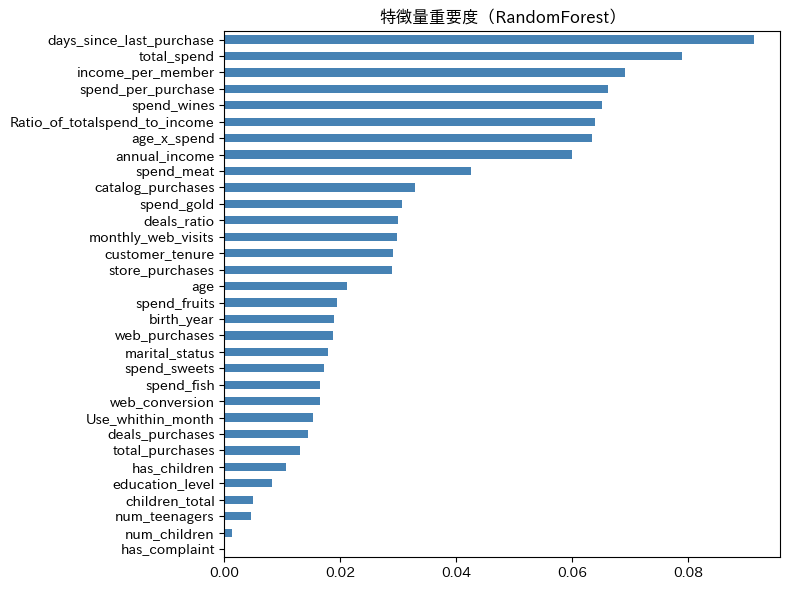

In [27]:
# 特徴量重要度: モデルがどの列をよく分岐に使ったかを見る
imp_model = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42).fit(X, y)
importances = pd.Series(imp_model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('特徴量重要度（RandomForest）')
plt.tight_layout()
plt.show()

　CV を見ると、**基準 0.830 → 特徴量追加後 0.826**（差 **約 −0.004**）。新しい特徴量を 2 つ足したのに、スコアはむしろ少し下がってしまいました。では **重要度が高いのに CV が上がらない**のはなぜでしょうか。上のプロットを見ると `total_spend` は `spend_*` 系の合計で、既存列と情報が重複しています。モデルはその列を頻繁に使う（重要度が高い）けれど、元の列が既に捉えていた情報なので CV は伸びない、ということが起きます。

　ここで大事なのは、「単体モデルの CV が少し下がったからすぐ戻す」という判断は早計だということです。この後の7章モデル比較・8章アンサンブル・9章チューニングと組み合わせると、合計のような特徴量が活きてくる場面もあります。今回は**このまま特徴量を保持して次のステップへ進みます**。実際このあと、モデル選びとチューニングで最終的に約 0.85 まで伸びていきます。

　基本の進め方は **仮説 → 追加 → CV で検証** です。単体でスコアが大きく下がるなら戻しますが、わずかな変化なら一旦残して全体の流れで判断する、という姿勢も大切です。

## 7. 様々なモデルの構築・比較

　特徴量を整えたので、次はモデル自体を変えてスコアを上げられないかを試します。なぜ何種類も試すのでしょうか。機械学習には「あらゆる場面で最強の手法は存在しない」という考え方（**No Free Lunch**）があり、データの性質によって得意なモデルが変わるからです。実際「いつも LightGBM が最強」とは限りません。そこで RandomForest・LogisticRegression・LightGBM・MLP・XGBoost の 5 つを CV で一斉に比較します。それぞれの素性を簡単に紹介します。

- **RandomForest**：たくさんの決定木を作って多数決を取るモデル。安定しやすい
- **LightGBM・XGBoost（勾配ブースティング）**：弱い木を順に重ね、前の木の間違いを次の木が直していく。表形式データでは最強格
- **LogisticRegression（線形モデル）**：特徴量の重み付き和から確率を出す古典。シンプルで解釈しやすい
- **MLP（ニューラルネット）**：層を重ねて複雑な関係を学べるモデルで、近年の**ディープラーニングの最も基本的な形**。柔軟だが、小さなデータでは過学習しやすい

　ここで一つ準備があります。`annual_income`（数万〜）と `num_children`（0〜数）のように、列ごとに値の大きさ（桁）が大きく違います。LogisticRegression と MLP は値の大きさをそのまま計算に使うので、このままだと「値が大きい列ほど重要」と誤解しがちです。そこで、各列の大きさをそろえる**標準化**（`StandardScaler`）を前処理として挟みます。一方 RandomForest などの決定木系は「ある値を境に分ける」仕組みなので、大きさの違いは気にせず、標準化は不要です。

In [28]:
# 不均衡対策: 評価はAUC（順位指標）、ロジスティック回帰は class_weight='balanced' を使用
models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42),
    'LogisticRegression': make_pipeline(StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
        random_state=42, verbose=-1),
    'MLP': make_pipeline(StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
        eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(n_estimators=300, learning_rate=0.05, depth=4,
        random_state=42, verbose=0),  # verbose=0で学習ログを非表示
}

cv_scores = {}
for name, model in models.items():
    mean_auc, _ = cv_auc(model, X, y)
    cv_scores[name] = mean_auc
    print(f'{name:20s} CV AUC = {mean_auc:.4f}')

RandomForest         CV AUC = 0.8332
LogisticRegression   CV AUC = 0.8253
LightGBM             CV AUC = 0.8484
MLP                  CV AUC = 0.7977
XGBoost              CV AUC = 0.8542
CatBoost             CV AUC = 0.8573


In [29]:
print(X.isnull().sum()[X.isnull().sum() > 0])


Series([], dtype: int64)


In [30]:
best_name = max(cv_scores, key=cv_scores.get)
print(f'\nこのデータで最も良かったモデル: {best_name}（CV AUC = {cv_scores[best_name]:.4f}）')


このデータで最も良かったモデル: CatBoost（CV AUC = 0.8573）


　このデータでは **XGBoost が最良（約 0.838）**、次いで LightGBM（約 0.83）・RandomForest（約 0.826）と続き、LogisticRegression（約 0.81）と MLP（約 0.78）はやや劣りました。一般に勾配ブースティングは表形式データで強く、MLP は木系に劣ることが多い——その通説どおりの並びです。ただし「いつも同じモデルが勝つ」とは限らないので、最良モデルは毎回 CV で確かめます。そして単体モデルにはそれぞれ限界があります。次は複数モデルを組み合わせて、さらに上げられるかを試します。

## 8. モデルのアンサンブリング

　単体モデルでは「ある行では間違える」という弱点が残ります。複数のモデルの予測を平均して、1 つが間違えても他が補い合うようにする——これを**アンサンブル**と言います。1 人の採点者より複数人の点数を平均した方が偏りが減って公平になりやすいのと同じで、複数モデルの予測を平均すると、それぞれの間違いが打ち消し合って予測が安定しやすくなります。うまくいく条件は「各モデルの精度が近いこと」と「間違える場面が異なること」です。LightGBM と XGBoost は同じ勾配ブースティングなので間違い方が似ていますが、RandomForest とは補い合える可能性があります。そこで今回は、この **LightGBM・XGBoost・RandomForest** の 3 つでアンサンブルします。やり方はシンプルで、3 つのモデルが出した「反応する確率」を足して 3 で割る——**単純平均**するだけです。アンサンブルも必ず上がるとは限らないため、CV で確認します。

In [31]:
def cv_auc_ensemble(model_list, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        preds = np.zeros(len(va_idx))
        for model in model_list:
            m = clone(model).fit(X.iloc[tr_idx], y.iloc[tr_idx])
            preds += m.predict_proba(X.iloc[va_idx])[:, 1]
        preds /= len(model_list)
        scores.append(roc_auc_score(y.iloc[va_idx], preds))
    return np.mean(scores)

# LightGBM / XGBoost / RandomForest を選んだ理由:
# 単体で強く、かつ学習アルゴリズムが異なるので「間違い方が分散」しやすい組み合わせ
ens_models = [models['LightGBM'], models['XGBoost'], models['RandomForest']]
ens_cv = cv_auc_ensemble(ens_models, X, y)
print(f'アンサンブル(単純平均) CV AUC = {ens_cv:.4f}')

アンサンブル(単純平均) CV AUC = 0.8570


　単純平均の CV は **約 0.846** で、最良の単体モデル（XGBoost 約 0.838）を上回りました。間違い方の異なる 3 モデルが補い合った成果です。もっとも、1 強の組み合わせだと平均が足を引っ張ることもあるので、上がったかは必ず CV で確認します。

　単純平均より高度な組み合わせが**スタッキング**です。各モデルの予測値を新しい入力にして、その上にもう一つのモデルを載せ、「どのモデルをどれだけ信用すればよいか」まで学習させる手法です。単純平均が全モデルを平等に扱うのに対し、スタッキングは、よく当てるモデルを重く・外しがちなモデルを軽く、と**重みづけを自動で調整**してくれます。ここでも **LightGBM・XGBoost・RandomForest** の 3 つをベースにし、その予測を束ねる役として LogisticRegression を載せます。

> **実行時間の目安**: このセルや次の9章（Optuna 30試行）は、Colab 無料環境で合計 3〜5 分ほどかかることがあります。気長に待ちましょう。

In [32]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[('lgbm', models['LightGBM']), ('xgb', models['XGBoost']), ('rf', models['RandomForest'])],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
)
stack_cv, _ = cv_auc(stack, X, y)
print(f'スタッキング CV AUC = {stack_cv:.4f}')

スタッキング CV AUC = 0.8573


　スタッキングの CV は **約 0.844** で、単純平均（約 0.846）と**ほぼ互角**——今回はわずかに届きませんでした（同じ 3 モデルで比べています）。スタッキングはうまくいけば単純平均を超えることもありますが、その差は小さく、**必ず勝つわけではありません**。手間に見合うかは場合によりけりなので、どちらを使うかは CV で比べて選びます。最終提出は10章で CV を一覧比較してから決めます。組み合わせよりも単体モデルをさらに強くしたい場合、次はハイパーパラメータのチューニングで仕上げます。

## 9. LightGBM のハイパーパラメータチューニング — Optuna

　特徴量とモデルの選択ができました。同じモデルでも設定値次第で性能は大きく変わります。この設定値（ハイパーパラメータ）を自動で探索してスコアをさらに上げます。グリッドサーチは候補が膨大になるため、有望な領域を賢く探索する **Optuna** を使います。特徴量が変わるたびに最適値も変わるため、特徴量が固まった後にチューニングするのが効率的です。

　主なパラメータの役割:
- `num_leaves` / `max_depth`: 大きいほど複雑なパターンを学べるが過学習しやすく、小さいほど未知データに強くなりやすい。
- `learning_rate`: 大きいほど一度に大きく学ぶが不安定。小さいほど安定するが多くの木が必要。
- `subsample` / `colsample_bytree`: 小さいほど学習に使うデータ・列をランダムに絞り、過学習を防ぐ。
- `reg_lambda`: モデルが複雑になりすぎるのを抑える強さ（正則化）。大きいほど過学習を防ぐ。

　ここでは例として、表形式データで扱いやすい **LightGBM** をチューニングします（基本は 7章で最も良かったモデルを選んでチューニングすると効果的です）。

　30 試行（n_trials=30）のため、Colab 無料環境では **2〜4 分**ほどかかります。プログレスバーで進捗を確認しながら待ちましょう。

In [33]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 600),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('num_leaves', 7, 63),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        min_child_samples=trial.suggest_int('min_child_samples', 10, 80),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    )
    model = LGBMClassifier(**params, random_state=42, verbose=-1)
    mean_auc, _ = cv_auc(model, X, y)
    return mean_auc

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)  # 試行回数。増やすほど時間がかかる
print(f'Optuna ベスト CV AUC = {study.best_value:.4f}  （基準 {baseline_cv:.4f}, 差 {study.best_value - baseline_cv:+.4f}）')

  0%|          | 0/100 [00:00<?, ?it/s]

Optuna ベスト CV AUC = 0.8710  （基準 0.8389, 差 +0.0320）


In [34]:
#XGBoostOptunaでチューニング
def objective_xgb(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 600),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth=trial.suggest_int('max_depth', 3, 8),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 20),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        eval_metric='logloss',
        random_state=42,
    )
    model = XGBClassifier(**params)
    mean_auc, _ = cv_auc(model, X, y)
    return mean_auc

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)
print(f'XGBoost Optuna CV AUC = {study_xgb.best_value:.4f}')

  0%|          | 0/100 [00:00<?, ?it/s]

XGBoost Optuna CV AUC = 0.8675


In [35]:
#CATBOOSTOptunaでチューニング
def objective_cat(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 600),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        depth=trial.suggest_int('depth', 3, 8),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bylevel=trial.suggest_float('colsample_bylevel', 0.6, 1.0),
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 10, 80),
        random_state=42,
        verbose=0,
    )
    model = CatBoostClassifier(**params)
    mean_auc, _ = cv_auc(model, X, y)
    return mean_auc

study_cat = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=100, show_progress_bar=True)
print(f'CatBoost Optuna CV AUC = {study_cat.best_value:.4f}')

  0%|          | 0/100 [00:00<?, ?it/s]

CatBoost Optuna CV AUC = 0.8703


In [36]:
tuned_lgbm = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
tuned_xgb = XGBClassifier(**study_xgb.best_params, random_state=42)
tuned_cat = CatBoostClassifier(**study_cat.best_params, random_state=42, verbose=0)
#rf = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)

ens_models = [tuned_lgbm, tuned_xgb, tuned_cat]#, rf]
ens_cv = cv_auc_ensemble(ens_models, X, y)
print(f'チューニング済みアンサンブル CV AUC = {ens_cv:.4f}')

チューニング済みアンサンブル CV AUC = 0.8730


/tmp/ipykernel_87119/953306836.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, vert=False, labels=top20[::-1],


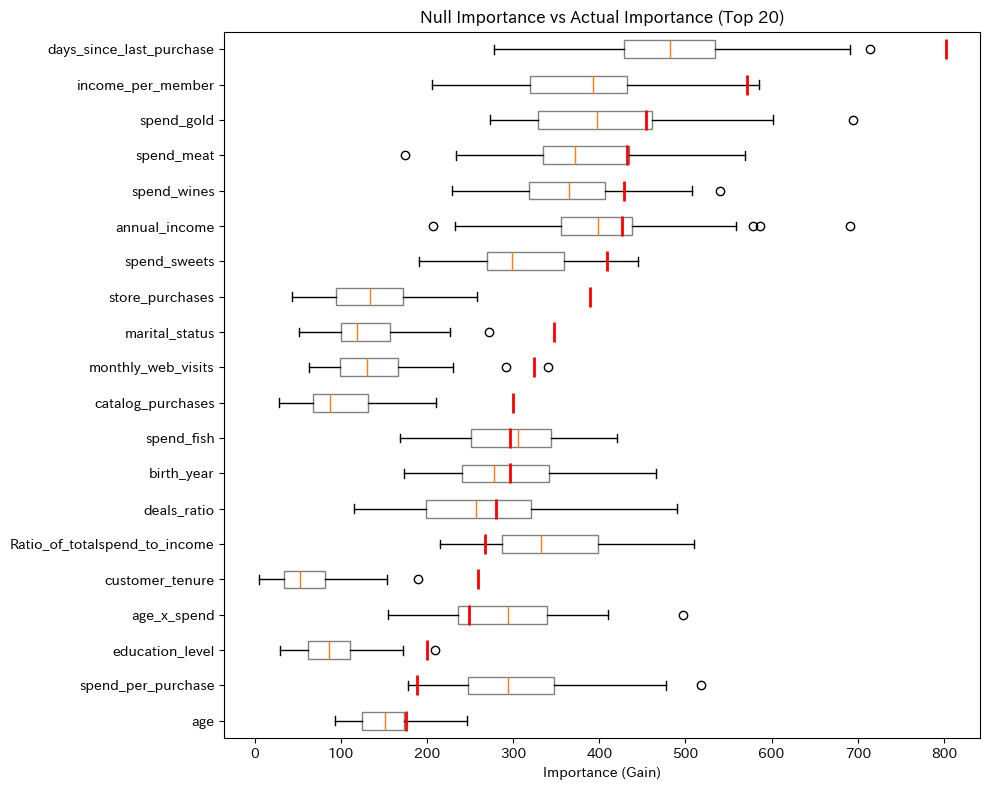

有用な特徴量(14個): ['education_level', 'marital_status', 'num_teenagers', 'days_since_last_purchase', 'spend_wines', 'spend_sweets', 'deals_purchases', 'web_purchases', 'catalog_purchases', 'store_purchases', 'monthly_web_visits', 'customer_tenure', 'Use_whithin_month', 'income_per_member']
削除候補(18個): ['birth_year', 'annual_income', 'num_children', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_gold', 'has_complaint', 'age', 'total_spend', 'children_total', 'Ratio_of_totalspend_to_income', 'total_purchases', 'deals_ratio', 'spend_per_purchase', 'has_children', 'age_x_spend', 'web_conversion']


In [37]:
#null importance
def null_importance(X, y, n_runs=50, random_state=42):
    model = LGBMClassifier(**study.best_params, random_state=random_state, verbose=-1)

    # 本物のimportance
    model.fit(X, y)
    real_imp = pd.Series(model.feature_importances_, index=X.columns)

    # Null importance
    null_imps = []
    for i in range(n_runs):
        y_shuffled = y.sample(frac=1, random_state=i).reset_index(drop=True)
        m = LGBMClassifier(**study.best_params, random_state=i, verbose=-1)
        m.fit(X, y_shuffled)
        null_imps.append(m.feature_importances_)

    null_imp_df = pd.DataFrame(null_imps, columns=X.columns)
    return real_imp, null_imp_df

real_imp, null_imp_df = null_importance(X, y, n_runs=50)

# 本物importanceの上位20列を表示
top20 = real_imp.sort_values(ascending=False).head(20).index

plt.figure(figsize=(10, 8))
data_to_plot = [null_imp_df[col].values for col in top20[::-1]]  # 上が高い順
plt.boxplot(data_to_plot, vert=False, labels=top20[::-1],
            patch_artist=True, boxprops=dict(facecolor='white', color='gray'))

# 実際のimportanceを赤線で重ねる
for i, col in enumerate(top20[::-1]):
    plt.plot(real_imp[col], i + 1, '|', color='red', markersize=15, markeredgewidth=2)

plt.xlabel('Importance (Gain)')
plt.title('Null Importance vs Actual Importance (Top 20)')
plt.tight_layout()
plt.show()

# useful_features の抽出
scores = {}
for col in X.columns:
    scores[col] = (null_imp_df[col] < real_imp[col]).mean()

useful_features = [col for col, s in scores.items() if s >= 0.8]
print(f'有用な特徴量({len(useful_features)}個): {useful_features}')
drop_cols = [col for col in X.columns if col not in useful_features]
print(f'削除候補({len(drop_cols)}個): {drop_cols}')

　Optuna ベスト CV AUC は **約 0.85**（基準 0.83 から **約 +0.02**）。これまでで最も高いスコアで、チューニング済み LightGBM が最良のモデルになりました。面白いのは、7章では XGBoost（約 0.838）が LightGBM（約 0.83）を上回っていたのに、チューニングで LightGBM が追い抜いたことです。同じモデルでも設定値次第でこれだけ変わる——チューニングの効き目がよく分かります。

　最後に、このベスト設定で test を予測します。ここでは **5-fold のそれぞれで学習した 5 つのモデルの予測を平均**します（k-fold アンサンブル）。各 fold は少しずつ違うデータで学習しているので、その予測を平均すると安定しやすくなります。（なお、ベスト設定で**全 train データ**を使って 1 つのモデルを学習し直す方法もよく使われます。より多くのデータを学習に使える、という利点があります。）

　さらに上を狙うなら、**各モデルをチューニングしてからアンサンブル／スタッキングする**のが定番の一手です。8章では素のモデルを束ねましたが、チューニングで強くしたモデルどうしを組み合わせると、単体よりもう一段スコアが伸びることがあります（本ノートでは LightGBM 単体までにとどめます）。

　次は、この平均予測から提出ファイルを作ります。

In [38]:
# ベスト設定で 5-fold それぞれ学習し、test 予測を平均する（k-fold アンサンブル）
##X_test = test[X.columns]  # train と同じ特徴量・順序に揃える
#skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#test_pred = np.zeros(len(test))
#for tr_idx, va_idx in skf.split(X, y):
    #m = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
    #m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    #test_pred += m.predict_proba(X_test)[:, 1] / skf.n_splits
#print('ベスト設定:', study.best_params)

## ベスト設定で 5-fold アンサンブルでtest予測
X_test = test[X.columns]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_pred = np.zeros(len(test))

for tr_idx, va_idx in skf.split(X, y):
    # LightGBM
    lgbm = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
    lgbm.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    test_pred += lgbm.predict_proba(X_test)[:, 1] / (skf.n_splits * 3)

    # XGBoost
    xgb = XGBClassifier(**study_xgb.best_params, random_state=42)
    xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    test_pred += xgb.predict_proba(X_test)[:, 1] / (skf.n_splits * 3)

    # RandomForest
    #rf_m = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)
    #rf_m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    #test_pred += rf_m.predict_proba(X_test)[:, 1] / (skf.n_splits * 4)

    # CatBoost
    cat = CatBoostClassifier(**study_cat.best_params, random_state=42, verbose=0)
    cat.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    test_pred += cat.predict_proba(X_test)[:, 1] / (skf.n_splits * 3)

print('ベスト設定:', study.best_params)
print('ベスト値:', study.best_value)


ベスト設定: {'n_estimators': 448, 'learning_rate': 0.011701354055495277, 'num_leaves': 34, 'max_depth': 7, 'min_child_samples': 44, 'subsample': 0.7745267226545406, 'colsample_bytree': 0.7694104393903227, 'reg_lambda': 0.32879558833319333}
ベスト値: 0.8709707752735788


## 10. 予測の出力・提出

　5〜9章でいくつかの手法を試してきました。どれを提出に使うべきかを CV スコアで比較して決めます。CV スコアが最も高いものが、手元で最も性能が高いモデルです。

In [39]:
# ここまでの CV スコアを一覧で比較し、最も高いものを提出に使う
summary = {'RF基準(5章)': baseline_cv}
summary.update({f'{k}(7章)': v for k, v in cv_scores.items()})
summary['アンサンブル(8章)'] = ens_cv
summary['スタッキング(8章)'] = stack_cv
summary['Optunaチューニング(9章)'] = study.best_value
for k, v in sorted(summary.items(), key=lambda kv: -kv[1]):
    print(f'{k:24s} CV AUC = {v:.4f}')

アンサンブル(8章)               CV AUC = 0.8730
Optunaチューニング(9章)         CV AUC = 0.8710
スタッキング(8章)               CV AUC = 0.8573
CatBoost(7章)             CV AUC = 0.8573
XGBoost(7章)              CV AUC = 0.8542
LightGBM(7章)             CV AUC = 0.8484
RF基準(5章)                 CV AUC = 0.8389
RandomForest(7章)         CV AUC = 0.8332
LogisticRegression(7章)   CV AUC = 0.8253
MLP(7章)                  CV AUC = 0.7977


　上の一覧のとおり、今回は **Optuna チューニング済み LightGBM（約 0.85）が最良**でした。これで test を予測して提出します。もし別の手法が上回っていれば、そちらを選ぶのが基本です。CV が高いほど未知のデータにも強い傾向がありますが、CV と本番のスコアは完全には一致しないこともあるので、CV を主な手がかりにしつつ過信しすぎないのがコツです。

In [40]:
# 9章で作った test_pred（5-fold アンサンブルの平均予測）から提出ファイルを作る
submission = pd.read_csv(PATH + 'sample_submission.csv')
submission['target'] = test_pred
submission.to_csv(PATH + 'submission_advanced.csv', index=False)
print('提出行数:', len(submission))
print('target範囲:', round(submission['target'].min(), 3), '〜', round(submission['target'].max(), 3))
submission.head()

提出行数: 672
target範囲: 0.002 〜 0.857


,customer_id,target
0,1568,0.690748
1,1569,0.441514
2,1570,0.155440
3,1571,0.006878
4,1572,0.071740


In [41]:
# Google Colab からダウンロードする場合
from google.colab import files
files.download(PATH + 'submission_advanced.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 提出してみましょう

作成した `submission_advanced.csv` を、コンペのページから提出しましょう。

> **注意**
> - ローカルの CV スコアと提出後の Public スコアは完全には一致しません。評価に使うデータが異なるためで、多少のズレは正常です。
> - 1日の提出回数に上限があります。計画的に提出しましょう。


> **Public と Private の違い**
>
> コンペのテストデータは2つの役割に分かれています。
> - **Public Leaderboard**: コンペ期間中に見えるスコア。提出のたびに確認できます。
> - **Private Leaderboard**: コンペ終了後に公開される、**最終順位を決める**スコア。期間中は見えません。
>
> Public スコアだけを追って調整しすぎると、Public にだけ過学習して Private で順位が下がることがあります。CV スコアと Public スコアの両方を見て、過学習していないか判断しましょう。終了後に多少順位が動くのは正常な範囲です。


## 11. まとめと次の打ち手

　提出ができました。EDA → 前処理 → ベースライン → CV → 特徴量 → モデル比較 → アンサンブル → チューニング → 提出という一周を体験しました。基準 **0.83** から出発し、特徴量（ほぼ変わらず）→ モデル比較（XGBoost 約 0.838）→ アンサンブル（約 0.846）→ Optuna（約 0.85）と、**CV を頼りに最終的に約 +0.02 引き上げてきました**。スコアをさらに上げるには、この改善サイクルを繰り返します。

**特徴量エンジニアリング（6章に追加して試す）**
- 「こういう顧客はキャンペーンに反応しやすいのでは？」と仮説を立て、それを表す新しい列（特徴量）を作って追加し、CV で効果を確かめる。これを繰り返すのが基本です。
- カテゴリ変数を **Target Encoding**（各カテゴリを、その target 平均で置き換える）で数値化してみる。情報漏洩を防ぐため、平均は CV の学習側だけで計算するのがコツです。

**不均衡データへの対策**
- 今回は反応あり（target=1）が約 15% の少数派でした。少数派を水増しする**オーバーサンプリング**（例: SMOTE）や、多数派を間引く**アンダーサンプリング**で改善することがあります。やりすぎると過学習や情報の損失につながるので、効果は必ず CV で確認します。

**チューニングの強化（9章を変更して試す）**
- `n_trials=30` を `50` や `100` に増やして最良 CV がさらに上がるか確認する。

**モデル・アンサンブルの改善（7・8章を変更して試す）**
- 組み合わせるモデルの数を増やす／種類の違うモデル（例: CatBoost など）を加えて多様化する。間違い方が異なるモデルどうしほど補い合いやすい。
- **各モデルをチューニングしてから束ねる**（アンサンブル／スタッキング）と、単体よりさらに伸びることがあります。
- スタッキングの**重ね方を変える**：束ねるメタモデル（最終段）を変えたり、段（層）を増やしたりする。

　あとは、この改善サイクルを自分で回していきましょう。**効きそうな工夫を一つ考えて実装し、10章の CV 一覧で効果を検証する**——この「**考える → 実装する → 検証する**」を繰り返すことで、スコアは少しずつ伸びていきます。一度に一つずつ試すと、何が効いたのかが分かりやすくなります。